In [1]:
import numpy as np

import train_vaes_phils_nb as vaes_nb
import pytorch_lightning as pl

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
def load_MSA(filename):
    return [''.join(s.strip().split('\n')[1:]) for s in 
                open(filename).read().strip().split('>')][1:]


MSA = load_MSA("../data/sadA_clean.fasta")
MSA_weights = np.load("../data/sadA_clean.weights.npy")

In [3]:
# load common aspects between models
dm = vaes_nb.ProtDataModule(MSA,64)
slen = len(MSA[0])

In [4]:
# train ConvVAE model 
# init model
kernel_size = 10
nlatent = 10
learning_rate=0.001
model = vaes_nb.ConvVAE(slen, kernel_size, nlatent,learning_rate)

# train 
logger = vaes_nb.CSVLogger('logs', name='CVAE')
trainer = pl.Trainer(logger=logger,max_epochs=50,gpus=0)
trainer.fit(model,dm)
#trainer.save_checkpoint("trained_VAE_model.ckpt")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs

  | Name         | Type            | Params
-------------------------------------------------
0 | embed        | Embedding       | 168   
1 | enc_conv_1   | Conv1d          | 1.3 K 
2 | enc_conv_2   | Conv1d          | 5.2 K 
3 | z_mean       | Linear          | 81.3 K
4 | z_log_var    | Linear          | 81.3 K
5 | dec_linear_1 | Linear          | 89.4 K
6 | dec_deconv_1 | ConvTranspose1d | 5.1 K 
7 | dec_deconv_2 | ConvTranspose1d | 1.3 K 
8 | rev_embed    | Linear          | 189   
-------------------------------------------------
265 K     Trainable params
0         Non-trainable params
265 K     Total params
1.061     Total estimated model params size (MB)


/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, val dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, train dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:322: UserWarning: The number of training samples (11) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lowe

Epoch 0:  85% 11/13 [00:00<00:00, 12.96it/s, loss=5.34e+04, v_num=5]
Validating: 0it [00:00, ?it/s]
Epoch 0: 100% 13/13 [00:00<00:00, 14.60it/s, loss=5.34e+04, v_num=5, val_ce_loss=4.23e+4]
Epoch 1:  85% 11/13 [00:00<00:00, 12.34it/s, loss=4.99e+04, v_num=5, val_ce_loss=4.23e+4, train_ce_loss=5.31e+4]
Validating: 0it [00:00, ?it/s]
Epoch 1: 100% 13/13 [00:01<00:00, 13.78it/s, loss=4.99e+04, v_num=5, val_ce_loss=33271.5, train_ce_loss=5.31e+4]
Epoch 2:  92% 12/13 [00:00<00:00, 14.94it/s, loss=4.27e+04, v_num=5, val_ce_loss=33271.5, train_ce_loss=4.55e+4]  
Validating: 0it [00:00, ?it/s]
Epoch 2: 100% 13/13 [00:00<00:00, 15.43it/s, loss=4.27e+04, v_num=5, val_ce_loss=3.16e+4, train_ce_loss=4.55e+4]
Epoch 3:  92% 12/13 [00:00<00:00, 14.79it/s, loss=3.87e+04, v_num=5, val_ce_loss=3.16e+4, train_ce_loss=3.87e+4]  
Validating: 0it [00:00, ?it/s]
Epoch 3: 100% 13/13 [00:00<00:00, 15.29it/s, loss=3.87e+04, v_num=5, val_ce_loss=3.05e+4, train_ce_loss=3.87e+4]
Epoch 4:  92% 12/13 [00:00<00:00, 1

Epoch 31:  92% 12/13 [00:00<00:00, 14.68it/s, loss=2.44e+04, v_num=5, val_ce_loss=2.09e+4, train_ce_loss=2.33e+4]  
Validating: 0it [00:00, ?it/s]
Epoch 31: 100% 13/13 [00:00<00:00, 15.17it/s, loss=2.44e+04, v_num=5, val_ce_loss=2.06e+4, train_ce_loss=2.33e+4]
Epoch 32:  92% 12/13 [00:00<00:00, 14.32it/s, loss=2.43e+04, v_num=5, val_ce_loss=2.06e+4, train_ce_loss=2.31e+4]  
Validating: 0it [00:00, ?it/s]
Epoch 32: 100% 13/13 [00:00<00:00, 14.82it/s, loss=2.43e+04, v_num=5, val_ce_loss=2.05e+4, train_ce_loss=2.31e+4]
Epoch 33:  92% 12/13 [00:00<00:00, 14.51it/s, loss=2.41e+04, v_num=5, val_ce_loss=2.05e+4, train_ce_loss=2.29e+4]  
Validating: 0it [00:00, ?it/s]
Epoch 33: 100% 13/13 [00:00<00:00, 15.03it/s, loss=2.41e+04, v_num=5, val_ce_loss=2.05e+4, train_ce_loss=2.29e+4]
Epoch 34:  92% 12/13 [00:00<00:00, 14.62it/s, loss=2.39e+04, v_num=5, val_ce_loss=2.05e+4, train_ce_loss=2.27e+4]  
Validating: 0it [00:00, ?it/s]
Epoch 34: 100% 13/13 [00:00<00:00, 15.19it/s, loss=2.39e+04, v_num=5, 

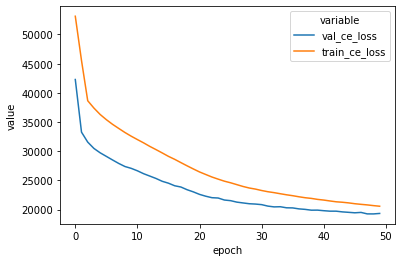

In [5]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
metrics_melt = pd.melt(metrics, id_vars=["epoch", "step"]).dropna()
g = sns.lineplot(x="epoch", y="value", hue="variable", data=metrics_melt)
g.get_figure().savefig(f"{logger.log_dir}/losses.png", dpi=300)

In [6]:
# train DCA model 
# init model
learning_rate=0.03
model = vaes_nb.ProtDCA(slen,learning_rate)

# train 
logger = vaes_nb.CSVLogger('logs', name='DCA')
trainer = pl.Trainer(logger=logger,max_epochs=50,gpus=0)
trainer.fit(model,dm)
#trainer.save_checkpoint("trained_DCA_model.ckpt")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs

  | Name   | Type      | Params
-------------------------------------
0 | embed  | Embedding | 441   
1 | linear | Linear    | 32.6 M
-------------------------------------
32.6 M    Trainable params
441       Non-trainable params
32.6 M    Total params
130.532   Total estimated model params size (MB)


Validation sanity check:  50% 1/2 [00:00<00:00,  7.60it/s]

/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, val dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, train dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:322: UserWarning: The number of training samples (11) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  85% 11/13 [00:01<00:00,  7.54it/s, loss=5e+04, v_num=26]   
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Epoch 0: 100% 13/13 [00:01<00:00,  7.99it/s, loss=5e+04, v_num=26]
Epoch 0: 100% 13/13 [00:01<00:00,  7.38it/s, loss=5e+04, v_num=26, val_ce_loss=3.88e+4]
Epoch 1:  92% 12/13 [00:01<00:00,  8.90it/s, loss=4.64e+04, v_num=26, val_ce_loss=3.88e+4, train_ce_loss=5e+4]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Validating:  50% 1/2 [00:00<00:00,  8.64it/s]
Epoch 1: 100% 13/13 [00:01<00:00,  8.30it/s, loss=4.64e+04, v_num=26, val_ce_loss=3.44e+4, train_ce_loss=5e+4]
Epoch 2:  92% 12/13 [00:01<00:00,  9.36it/s, loss=4.11e+04, v_num=26, val_ce_loss=3.44e+4, train_ce_loss=4.4e+4]
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Validating:  50% 1/2 [00:00<00:00,  8.31it/s]
Epoch 2: 100% 13/13 [00:01<00:00,  8.55it/s, loss=4.11e+04, v_num=26, val_ce_loss=3.1e+4, train_ce_loss=4.4e+4] 
Epoch 3:  92% 12/13 [00:01<0

Epoch 24:  92% 12/13 [00:01<00:00, 10.79it/s, loss=2.77e+04, v_num=26, val_ce_loss=2.36e+4, train_ce_loss=2.77e+4]  
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Validating:  50% 1/2 [00:00<00:00,  9.76it/s]
Epoch 24: 100% 13/13 [00:01<00:00,  9.89it/s, loss=2.77e+04, v_num=26, val_ce_loss=2.36e+4, train_ce_loss=2.77e+4]
Epoch 25:  92% 12/13 [00:01<00:00, 10.34it/s, loss=2.76e+04, v_num=26, val_ce_loss=2.36e+4, train_ce_loss=2.77e+4]  
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Validating:  50% 1/2 [00:00<00:00,  9.22it/s]
Epoch 25: 100% 13/13 [00:01<00:00,  9.46it/s, loss=2.76e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.77e+4]
Epoch 26:  92% 12/13 [00:01<00:00,  9.89it/s, loss=2.77e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.76e+4]  
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Validating:  50% 1/2 [00:00<00:00,  9.35it/s]
Epoch 26: 100% 13/13 [00:01<00:00,  9.15it/s, loss=2.77e+04, v_num=26, val

Epoch 47:  92% 12/13 [00:01<00:00, 10.29it/s, loss=2.76e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.75e+4]  
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Epoch 47: 100% 13/13 [00:01<00:00,  9.48it/s, loss=2.76e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.75e+4]
Epoch 48:  92% 12/13 [00:01<00:00, 10.77it/s, loss=2.75e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.75e+4]  
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Epoch 48: 100% 13/13 [00:01<00:00,  9.86it/s, loss=2.75e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.75e+4]
Epoch 49:  92% 12/13 [00:01<00:00, 10.05it/s, loss=2.75e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.75e+4]  
Validating: 0it [00:00, ?it/s]
Validating:   0% 0/2 [00:00<?, ?it/s]
Validating:  50% 1/2 [00:00<00:00,  8.60it/s]
Epoch 49: 100% 13/13 [00:01<00:00,  9.18it/s, loss=2.75e+04, v_num=26, val_ce_loss=2.35e+4, train_ce_loss=2.75e+4]
Epoch 49: 100% 13/13 [00:01<00:00,  7.52it/s, loss=

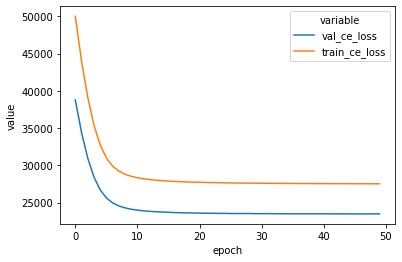

In [7]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
metrics_melt = pd.melt(metrics, id_vars=["epoch", "step"]).dropna()
g = sns.lineplot(x="epoch", y="value", hue="variable", data=metrics_melt)
g.get_figure().savefig(f"{logger.log_dir}/losses.png", dpi=300)